# Marco de Transferencia Tecnológica
Sección 1: Relación con el Paper y MobileNetV4: Implementación de Transferencia Inductiva basada en MobileNetV4. Se aprovechan las representaciones convolucionales jerárquicas universales entrenadas en ImageNet, adaptando el clasificador para mitigar el Catastrophic Forgetting mediante el congelamiento total de las capas base.

In [1]:
# Limpiamos intentos anteriores por si acaso
!rm -rf src_folder

# Clonación de src y requirements
!git clone https://github.com/Esme0123/CasoEstudio3.git src_folder
!cp -r src_folder/src .
!pip install -r src_folder/requirements.txt

Cloning into 'src_folder'...
remote: Enumerating objects: 59, done.
remote: Counting objects: 100% (59/59), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 59 (delta 12), reused 17 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (59/59), 203.02 KiB | 1.53 MiB/s, done.
Resolving deltas: 100% (12/12), done.
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 83.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.5/755.5 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 44.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 42.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 M

In [1]:
# Tu bloque de código con json.dump para las credenciales de Kaggle...

from src.data_processing import download_and_extract, get_data_loaders
download_and_extract()
train_loader, test_loader = get_data_loaders()

Descargando dataset desde Kaggle...
Dataset listo y extraído.


In [2]:
# Inicialización del Modelo Avanzado
from src.architecture_models import get_mobilenet_v4
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model_advanced = get_mobilenet_v4().to(device)
# Fase de entrenamiento idéntica con lr optimizado (1e-4) para fine-tuning

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/22.1M [00:00<?, ?B/s]

# Análisis de Error Avanzado e Inteligencia Artificial Explicable (XAI)
Sección 8: Análisis de Error (Grad-CAM): Incorporamos mapas de activación por gradientes sobre las capas convolucionales finales de MobileNetV4. Esto permite auditar si los patrones activados corresponden a las fisuras o si existen sesgos por reflejos lumínicos o artefactos del fondo.

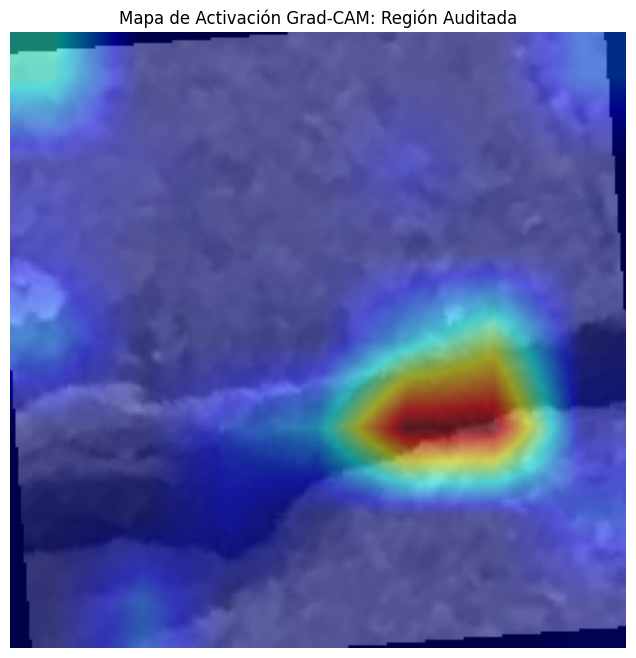

In [8]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image
import numpy as np
import matplotlib.pyplot as plt

# Extraemos un lote de imágenes de prueba para auditar
images, labels = next(iter(test_loader))

# Activamos el rastreo de gradientes estrictamente para la capa objetivo
# que Grad-CAM necesita auditar, sobreescribiendo el congelamiento previo.
for param in model_advanced.blocks[-1].parameters():
    param.requires_grad = True

# Apuntamos a la última capa convolucional de MobileNetV4
target_layers = [model_advanced.blocks[-1]]
cam = GradCAM(model=model_advanced, target_layers=target_layers)

# Preparamos el tensor de la primera imagen del lote
input_tensor = images[0].unsqueeze(0).to(device)

# Generamos el mapa de calor (ahora sí encontrará gradientes)
grayscale_cam = cam(input_tensor=input_tensor, targets=[ClassifierOutputTarget(1)])[0, :]

# Procesamos la imagen original para poder superponer los colores
rgb_img = images[0].permute(1, 2, 0).numpy()
rgb_img = (rgb_img - rgb_img.min()) / (rgb_img.max() - rgb_img.min())

# Generamos la visualización final
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(8, 8))
plt.imshow(visualization)
plt.title("Mapa de Activación Grad-CAM: Región Auditada")
plt.axis('off')
plt.show()
